In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Minimal RK4 step for scalars
def step_rk4(y, t, step, dy, **kwargs):
    half = step / 2.0
    k1 = dy(t, y, **kwargs)
    k2 = dy(t + half, y + k1 * half, **kwargs)
    k3 = dy(t + half, y + k2 * half, **kwargs)
    k4 = dy(t + step, y + k3 * step, **kwargs)
    return y + (step / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

In [38]:
def softmax(arr: np.ndarray) -> np.ndarray:
    exp = np.exp(arr)
    return exp / exp.sum()

In [ ]:
def poisson_neuron(t: np.ndarray, mean_frequency: int) -> np.ndarray:
    """
    Simulates a neuron that stochastically spikes at a mean frequency.
    The probability of a spike taking place is given by a poisson distribution.

    Args:
        t (np.ndarray): Array from t=0 which determines the simulations lenght and step size.
        frequency (int): The mean rate at which spikes will occur

    Returns:
        np.ndarray: Binary spike array
    """

    spiking_probability = mean_frequency * (t[1] - t[0])
    return np.random.choice([0, 1], size=t.shape, p=[1-spiking_probability, spiking_probability])

In [45]:
import seaborn as sns
sns.set(style="whitegrid")


def pretty_plot_results(times, potentials, intensities, spikes, title="Simulation"):
    import numpy as _np
    times = _np.array(times)
    times_ms = times * 1000.0
    potentials = _np.array(potentials)
    intensities = _np.array(intensities)
    spikes = _np.array(spikes)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    pal = sns.color_palette("deep")
    color_p = pal[0]
    color_i = pal[1]

    ax.plot(times_ms, potentials, color=color_p,
            lw=1.6, label="Membrane potential")
    ax.set_ylabel("Potential", color=color_p)
    ax.set_xlabel("Time (ms)")
    ax.tick_params(axis="y", labelcolor=color_p)

    ax2 = ax.twinx()
    ax2.fill_between(times_ms, intensities, color=color_i, alpha=0.25)
    ax2.plot(times_ms, intensities, color=color_i,
             lw=1.0, alpha=0.9, label="Intensity")
    ax2.set_ylabel("Intensity", color=color_i)
    ax2.tick_params(axis="y", labelcolor=color_i)

    # Plot spikes as vertical markers (raster-like) aligned to potential axis
    spike_times = times_ms[spikes.astype(
        bool)] if spikes.size else _np.array([])
    if spike_times.size > 0:
        ylim = ax.get_ylim()
        height = ylim[1] - ylim[0]
        line_y = ylim[0] + 0.85 * height
        ax.vlines(spike_times, line_y - 0.02 * height, line_y +
                  0.02 * height, color="red", alpha=0.9, linewidth=1.2)
        ax.scatter(spike_times, _np.ones_like(spike_times) * (line_y +
                   0.04 * height), color="red", s=18, zorder=5, label="Spikes")

    # Combined legend
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=9)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [236]:
STEP_SIZE = 1  # ms
SIMULATION_LENGTH = 1000  # ms
REFRACTORY_PERIOD = 5  # steps
times = np.arange(0, SIMULATION_LENGTH/(STEP_SIZE*1000), STEP_SIZE/1000)
delta_time = times[1] - times[0]

Input neurons

In [160]:
def neuronal_population_signal(times: np.ndarray, frequencies: np.ndarray, neuron_weights: np.ndarray = np.array([])) -> np.ndarray:
    neurons = np.zeros(shape=(frequencies.shape[0], times.shape[0]))
    for i, freq in enumerate(frequencies):
        neurons[i] = poisson_neuron(times, freq)

    if not neuron_weights.size > 0:
        neuron_weights = softmax(np.random.random(size=frequencies.shape))

    return np.matmul(neuron_weights, neurons)


def sample_neurons(probabilities: np.ndarray) -> np.ndarray:

    # vectorized sampling per neuron: uniform random < p -> spike
    spikes = (np.random.random(size=probabilities.shape)
              < probabilities).astype(int)
    return spikes


def compute_signal(spikes: np.ndarray, weights: np.ndarray) -> float:
    return np.dot(spikes, weights)

In [238]:
frequencies = 20 * np.ones(10)
frequencies[6] = 150
probabilities = delta_time * frequencies
probabilities = np.clip(probabilities, 0, 1)

Output neuron

In [230]:
TAU = 20  # ms
INVERSE_TAU = 1 / TAU
REST_POTENTIAL = 0  # V
RESISTANCE = 1  # ohm
SPIKE_THRESHOLD = 0.2  # V

# Same for potentiation and depression but usually made different for each
LEARNING_WINDWOW = 0.01

# Same for potentiation and depression but usually made different for each
POTENTIATION = 0.01


def derivative_potential(t, membrane_potential, input_signal):
    return (RESISTANCE * input_signal - (membrane_potential - REST_POTENTIAL)) * INVERSE_TAU


def spiked(v: float) -> bool:
    return v >= SPIKE_THRESHOLD


def spike_response(v: float, v_rest: float) -> float:
    return v_rest


def delta_weights(delta_times: np.ndarray) -> np.ndarray:
    return np.sign(delta_times) * POTENTIATION * np.exp(-1 * np.abs(delta_times/LEARNING_WINDWOW))

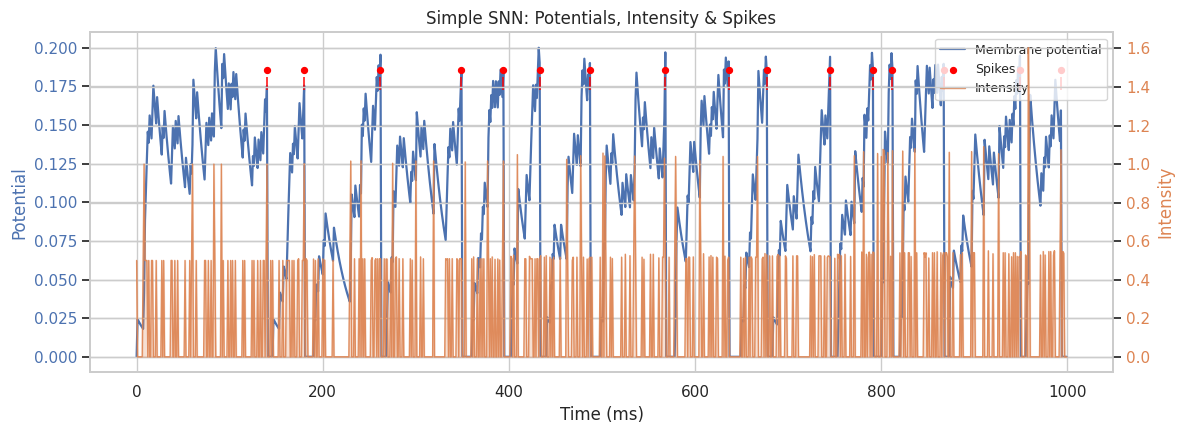

20.0: 0.52
20.0: 0.53
20.0: 0.53
20.0: 0.53
20.0: 0.53
20.0: 0.54
150.0: 0.55
20.0: 0.56
20.0: 0.54
20.0: 0.53


In [237]:
potential = REST_POTENTIAL
potentials = []
postsynaptic_spike_times = 0
spikes = []
spike_cooldown = 0

neurons = np.zeros_like(probabilities)
presynaptic_spike_times = np.zeros_like(neurons)
weights = 0.5 * np.ones_like(neurons)
input_signal = []


for i, t in enumerate(times):
    potentials.append(potential)

    neurons = sample_neurons(probabilities)
    for j, spike in enumerate(neurons):
        if spike:
            presynaptic_spike_times[j] = t

    input_signal.append(compute_signal(neurons, weights))

    if spike_cooldown > 0:
        spike_cooldown -= 1
        spikes.append(0)
        continue

    potential = step_rk4(potential, t, STEP_SIZE,
                         derivative_potential, input_signal=input_signal[i])

    if spiked(potential):
        spikes.append(1)
        postsynaptic_spike_times = t
        potential = spike_response(potential, REST_POTENTIAL)
        spike_cooldown = REFRACTORY_PERIOD

        # update weights
        weights += delta_weights(postsynaptic_spike_times -
                                 presynaptic_spike_times)

    else:
        spikes.append(0)

# Use the new pretty plotting helper: convert times (s) to ms inside helper
pretty_plot_results(times, potentials, input_signal, spikes,
                    title="Simple SNN: Potentials, Intensity & Spikes")

for freq, weight in zip(frequencies, weights):
    print(f"{freq}: {weight:.2f}")